In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/train_data.csv")
df.head(5)

,UserID,ItemID,Rating,Timestamp
0,0,32,4,978824330
1,0,34,4,978824330
2,0,4,5,978824291
3,0,35,4,978824291
4,0,30,4,978824291


In [3]:
popularity_item_wise = df.groupby("ItemID")["UserID"].nunique().to_frame()
popularity_item_wise

,UserID
ItemID,
0,1721
1,521
2,632
3,1292
4,1694
...,...
3701,2
3702,1
3703,1


In [4]:
popularity_item_wise.columns = ["Freq"]
popularity_item_wise

,Freq
ItemID,
0,1721
1,521
2,632
3,1292
4,1694
...,...
3701,2
3702,1
3703,1


In [5]:
popularity_item_wise.reset_index(inplace=True)
popularity_item_wise

,ItemID,Freq
0,0,1721
1,1,521
2,2,632
3,3,1292
4,4,1694
...,...,...
3699,3701,2
3700,3702,1
3701,3703,1
3702,3704,1


In [6]:
popularity_item_wise["Freq"] = popularity_item_wise["Freq"] / max(popularity_item_wise["Freq"])
popularity_item_wise

,ItemID,Freq
0,0,0.505433
1,1,0.153010
2,2,0.185609
3,3,0.379442
4,4,0.497504
...,...,...
3699,3701,0.000587
3700,3702,0.000294
3701,3703,0.000294
3702,3704,0.000294


In [7]:
max(popularity_item_wise["Freq"]), min(popularity_item_wise["Freq"])

(1.0, 0.0002936857562408223)

In [8]:
popularity_item_wise

,ItemID,Freq
0,0,0.505433
1,1,0.153010
2,2,0.185609
3,3,0.379442
4,4,0.497504
...,...,...
3699,3701,0.000587
3700,3702,0.000294
3701,3703,0.000294
3702,3704,0.000294


In [9]:
popularity_item_wise.sort_values("Freq", ascending=False, inplace=True)
popularity_item_wise.reset_index(drop=True, inplace=True)

In [10]:
popularity_item_wise

,ItemID,Freq
0,104,1.000000
1,124,0.876652
2,44,0.874596
3,64,0.844640
4,113,0.781204
...,...,...
3699,3637,0.000294
3700,3702,0.000294
3701,3703,0.000294
3702,3704,0.000294


In [11]:
popularity_item_wise.index = list(range(1,3705))
popularity_item_wise

,ItemID,Freq
1,104,1.000000
2,124,0.876652
3,44,0.874596
4,64,0.844640
5,113,0.781204
...,...,...
3700,3637,0.000294
3701,3702,0.000294
3702,3703,0.000294
3703,3704,0.000294


In [12]:
popularity_item_wise.reset_index(inplace=True)

In [13]:
popularity_item_wise.columns = ["Rank", "ItemID", "Freq"]
popularity_item_wise

,Rank,ItemID,Freq
0,1,104,1.000000
1,2,124,0.876652
2,3,44,0.874596
3,4,64,0.844640
4,5,113,0.781204
...,...,...,...
3699,3700,3637,0.000294
3700,3701,3702,0.000294
3701,3702,3703,0.000294
3702,3703,3704,0.000294


In [14]:
popularity_item_wise.to_csv("popularity_item_wise.csv", index=False)

In [15]:
popularity_item_wise = pd.read_csv("popularity_item_wise.csv")

popularity_item_wise

,Rank,ItemID,Freq
0,1,104,1.000000
1,2,124,0.876652
2,3,44,0.874596
3,4,64,0.844640
4,5,113,0.781204
...,...,...,...
3699,3700,3637,0.000294
3700,3701,3702,0.000294
3701,3702,3703,0.000294
3702,3703,3704,0.000294


## Load the embeddings

In [47]:
embeddings = pd.read_csv("/home/dhruv/Documents/NCF/NCF_Recommendation/item_embeddings_16.csv")

embeddings

,item_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0,-0.514110,-0.040921,-0.255458,-0.484849,-0.097003,0.202927,-0.612266,0.292524,-0.050430,0.360699,-0.278016,0.646636,0.041590,0.437690,0.409958,0.175688
1,1,-0.145532,-0.249202,-0.026037,0.532297,0.188935,-0.282285,0.269755,0.040717,0.124007,0.127709,0.138536,-0.020743,-0.085377,-0.030429,-0.262835,-0.074497
2,2,-0.559834,-0.390347,-0.254704,0.330007,-0.089569,-0.489502,-0.409745,-0.145153,-0.155109,-0.285833,-0.026832,0.100784,0.098438,0.049047,0.118674,0.012164
3,3,-0.018108,-0.501886,0.306822,0.416597,0.176000,0.090546,0.087603,-0.301356,0.279925,-0.540126,-0.363079,0.181719,-0.043423,0.171838,0.061025,0.100490
4,4,-0.003181,-0.302803,-0.276654,0.836615,-0.051096,0.174919,0.021186,-0.240488,0.086213,-0.238350,-0.259370,0.483003,-0.288134,0.281190,0.325996,0.199000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3701,3701,1.250555,-1.140065,1.754596,1.400977,0.945865,-1.624635,1.668541,0.277663,1.263678,0.870135,2.358717,-2.614959,1.793778,-2.595533,-2.888462,-2.900881
3702,3702,1.352040,-1.084617,1.916589,1.242819,1.101057,-1.690751,1.798314,0.188261,1.139120,0.882645,2.528366,-2.660469,1.704438,-2.856904,-3.080355,-2.516681
3703,3703,1.363777,-1.113016,1.882341,1.278585,1.092160,-1.609767,1.906189,0.226497,1.031066,0.899117,2.546404,-2.755696,1.661396,-2.913403,-3.137361,-2.413177
3704,3704,1.410402,-1.009072,1.961151,1.299273,0.986024,-1.591147,1.921781,0.132934,0.934001,0.914848,2.645501,-2.655416,1.637481,-2.968494,-3.190404,-2.386067


In [48]:
embedding_cols = embeddings.columns[1:]

In [49]:
embedding_cols

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15'],
      dtype='object')

In [51]:
X = embeddings[embedding_cols].to_numpy(dtype=float)
X

array([[-0.51410985, -0.04092107, -0.25545803, ...,  0.4376902 ,
         0.40995774,  0.17568842],
       [-0.14553219, -0.24920247, -0.02603652, ..., -0.03042924,
        -0.26283458, -0.0744974 ],
       [-0.5598344 , -0.39034656, -0.25470394, ...,  0.04904689,
         0.11867355,  0.01216417],
       ...,
       [ 1.3637772 , -1.113016  ,  1.8823415 , ..., -2.913403  ,
        -3.1373615 , -2.413177  ],
       [ 1.4104018 , -1.0090722 ,  1.9611511 , ..., -2.9684935 ,
        -3.190404  , -2.3860672 ],
       [ 1.2932152 , -1.1809517 ,  1.9712565 , ..., -2.9142497 ,
        -3.2094662 , -2.4259079 ]], shape=(3706, 16))

In [52]:
U_reduced, s, Vt_reduced = np.linalg.svd(X, full_matrices=False)
U_reduced.shape, s.shape, Vt_reduced.shape

((3706, 16), (16,), (16, 16))

In [53]:
r = U_reduced.shape[1]


In [54]:
r

16

In [55]:
U_reduced

array([[-6.13931950e-03,  3.30159738e-03, -1.33203169e-02, ...,
        -1.21212946e-02,  3.38840757e-02,  2.62098437e-02],
       [ 2.55871228e-03, -2.83836647e-03, -9.75786027e-05, ...,
        -2.20561036e-02,  1.00378492e-02,  3.71671563e-03],
       [-1.35631644e-03,  1.20943225e-02, -9.07068971e-03, ...,
         1.74356590e-02,  1.88335989e-03,  3.13885005e-03],
       ...,
       [ 4.50832271e-02, -1.47242615e-03, -1.77490235e-03, ...,
        -1.42209953e-02, -1.66259695e-02, -6.41525807e-03],
       [ 4.51947861e-02, -1.99105898e-03,  4.06151675e-03, ...,
        -9.61463567e-03, -4.76034552e-03,  2.59608586e-03],
       [ 4.53549950e-02,  9.99376260e-04, -1.84223237e-03, ...,
        -3.19225342e-02, -1.04206722e-02, -1.34478492e-03]],
      shape=(3706, 16))

In [56]:
df_2 = pd.DataFrame(U_reduced)
df_2

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,-0.006139,0.003302,-0.013320,0.033551,0.006899,0.014592,0.010346,-0.013894,0.012852,-0.003842,0.000810,0.017399,-0.019395,-0.012121,0.033884,0.026210
1,0.002559,-0.002838,-0.000098,-0.010365,0.001281,-0.014322,-0.016066,-0.021063,0.013945,-0.022150,0.000181,0.038942,-0.001427,-0.022056,0.010038,0.003717
2,-0.001356,0.012094,-0.009071,0.006361,0.005782,-0.050452,-0.008936,-0.015290,0.028696,-0.020153,0.001980,0.012010,0.003709,0.017436,0.001883,0.003139
3,-0.000868,0.013288,-0.005287,-0.029578,-0.015839,-0.014911,-0.005480,0.001832,0.026141,0.002334,-0.050048,0.006868,-0.011600,-0.025750,0.027782,-0.004100
4,-0.003653,0.003409,-0.007444,-0.037751,-0.002404,-0.016564,0.001520,-0.023281,0.024667,-0.016441,0.006938,0.033537,-0.000927,-0.021184,0.008800,0.029099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3701,0.043737,0.012544,-0.015253,-0.020552,0.023958,-0.013164,-0.048386,0.006971,-0.029220,0.004077,0.005003,0.006133,0.009631,-0.017146,0.013314,0.015975
3702,0.044853,0.003598,-0.003245,-0.017523,0.010479,-0.009725,-0.050121,-0.002343,-0.015456,0.015199,-0.003301,-0.018056,0.016169,-0.004834,-0.001536,0.003995
3703,0.045083,-0.001472,-0.001775,-0.018938,0.006207,-0.012911,-0.047905,-0.006037,-0.019229,0.020446,-0.001239,-0.016813,0.018035,-0.014221,-0.016626,-0.006415
3704,0.045195,-0.001991,0.004062,-0.020452,0.005373,-0.013265,-0.042100,-0.011033,-0.019993,0.024435,0.010922,-0.028007,0.016771,-0.009615,-0.004760,0.002596


In [57]:
df_2.columns = [f"{i}_reduced" for i in range(16)]
df_2

,0_reduced,1_reduced,2_reduced,3_reduced,4_reduced,5_reduced,6_reduced,7_reduced,8_reduced,9_reduced,10_reduced,11_reduced,12_reduced,13_reduced,14_reduced,15_reduced
0,-0.006139,0.003302,-0.013320,0.033551,0.006899,0.014592,0.010346,-0.013894,0.012852,-0.003842,0.000810,0.017399,-0.019395,-0.012121,0.033884,0.026210
1,0.002559,-0.002838,-0.000098,-0.010365,0.001281,-0.014322,-0.016066,-0.021063,0.013945,-0.022150,0.000181,0.038942,-0.001427,-0.022056,0.010038,0.003717
2,-0.001356,0.012094,-0.009071,0.006361,0.005782,-0.050452,-0.008936,-0.015290,0.028696,-0.020153,0.001980,0.012010,0.003709,0.017436,0.001883,0.003139
3,-0.000868,0.013288,-0.005287,-0.029578,-0.015839,-0.014911,-0.005480,0.001832,0.026141,0.002334,-0.050048,0.006868,-0.011600,-0.025750,0.027782,-0.004100
4,-0.003653,0.003409,-0.007444,-0.037751,-0.002404,-0.016564,0.001520,-0.023281,0.024667,-0.016441,0.006938,0.033537,-0.000927,-0.021184,0.008800,0.029099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3701,0.043737,0.012544,-0.015253,-0.020552,0.023958,-0.013164,-0.048386,0.006971,-0.029220,0.004077,0.005003,0.006133,0.009631,-0.017146,0.013314,0.015975
3702,0.044853,0.003598,-0.003245,-0.017523,0.010479,-0.009725,-0.050121,-0.002343,-0.015456,0.015199,-0.003301,-0.018056,0.016169,-0.004834,-0.001536,0.003995
3703,0.045083,-0.001472,-0.001775,-0.018938,0.006207,-0.012911,-0.047905,-0.006037,-0.019229,0.020446,-0.001239,-0.016813,0.018035,-0.014221,-0.016626,-0.006415
3704,0.045195,-0.001991,0.004062,-0.020452,0.005373,-0.013265,-0.042100,-0.011033,-0.019993,0.024435,0.010922,-0.028007,0.016771,-0.009615,-0.004760,0.002596


In [58]:
embedding_cols = df_2.columns
embedding_cols

Index(['0_reduced', '1_reduced', '2_reduced', '3_reduced', '4_reduced',
       '5_reduced', '6_reduced', '7_reduced', '8_reduced', '9_reduced',
       '10_reduced', '11_reduced', '12_reduced', '13_reduced', '14_reduced',
       '15_reduced'],
      dtype='object')

In [61]:
final_df = pd.concat([embeddings, df_2], axis=1)

In [62]:
final_df["l2_norm"] = np.sqrt((final_df[embedding_cols] ** 2).sum(axis=1))
final_df

,item_index,0,1,2,3,4,5,6,7,8,...,7_reduced,8_reduced,9_reduced,10_reduced,11_reduced,12_reduced,13_reduced,14_reduced,15_reduced,l2_norm
0,0,-0.514110,-0.040921,-0.255458,-0.484849,-0.097003,0.202927,-0.612266,0.292524,-0.050430,...,-0.013894,0.012852,-0.003842,0.000810,0.017399,-0.019395,-0.012121,0.033884,0.026210,0.068948
1,1,-0.145532,-0.249202,-0.026037,0.532297,0.188935,-0.282285,0.269755,0.040717,0.124007,...,-0.021063,0.013945,-0.022150,0.000181,0.038942,-0.001427,-0.022056,0.010038,0.003717,0.061929
2,2,-0.559834,-0.390347,-0.254704,0.330007,-0.089569,-0.489502,-0.409745,-0.145153,-0.155109,...,-0.015290,0.028696,-0.020153,0.001980,0.012010,0.003709,0.017436,0.001883,0.003139,0.069802
3,3,-0.018108,-0.501886,0.306822,0.416597,0.176000,0.090546,0.087603,-0.301356,0.279925,...,0.001832,0.026141,0.002334,-0.050048,0.006868,-0.011600,-0.025750,0.027782,-0.004100,0.080086
4,4,-0.003181,-0.302803,-0.276654,0.836615,-0.051096,0.174919,0.021186,-0.240488,0.086213,...,-0.023281,0.024667,-0.016441,0.006938,0.033537,-0.000927,-0.021184,0.008800,0.029099,0.075864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3701,3701,1.250555,-1.140065,1.754596,1.400977,0.945865,-1.624635,1.668541,0.277663,1.263678,...,0.006971,-0.029220,0.004077,0.005003,0.006133,0.009631,-0.017146,0.013314,0.015975,0.087262
3702,3702,1.352040,-1.084617,1.916589,1.242819,1.101057,-1.690751,1.798314,0.188261,1.139120,...,-0.002343,-0.015456,0.015199,-0.003301,-0.018056,0.016169,-0.004834,-0.001536,0.003995,0.078576
3703,3703,1.363777,-1.113016,1.882341,1.278585,1.092160,-1.609767,1.906189,0.226497,1.031066,...,-0.006037,-0.019229,0.020446,-0.001239,-0.016813,0.018035,-0.014221,-0.016626,-0.006415,0.082765
3704,3704,1.410402,-1.009072,1.961151,1.299273,0.986024,-1.591147,1.921781,0.132934,0.934001,...,-0.011033,-0.019993,0.024435,0.010922,-0.028007,0.016771,-0.009615,-0.004760,0.002596,0.082969


In [63]:
embeddings_final_df = final_df[["item_index", "l2_norm"]]
embeddings_final_df

,item_index,l2_norm
0,0,0.068948
1,1,0.061929
2,2,0.069802
3,3,0.080086
4,4,0.075864
...,...,...
3701,3701,0.087262
3702,3702,0.078576
3703,3703,0.082765
3704,3704,0.082969


In [64]:
embeddings_final_df.columns = ["ItemID", "l2_norm"]

embeddings_final_df

,ItemID,l2_norm
0,0,0.068948
1,1,0.061929
2,2,0.069802
3,3,0.080086
4,4,0.075864
...,...,...
3701,3701,0.087262
3702,3702,0.078576
3703,3703,0.082765
3704,3704,0.082969


In [65]:
embeddings_final_df.sort_values("l2_norm", ascending=False, inplace=True)

embeddings_final_df

/tmp/ipykernel_95343/3813055162.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  embeddings_final_df.sort_values("l2_norm", ascending=False, inplace=True)


,ItemID,l2_norm
3604,3604,0.167520
3584,3584,0.154834
3548,3548,0.154735
3666,3666,0.148477
124,124,0.147635
...,...,...
289,289,0.027335
1125,1125,0.027181
2064,2064,0.025275
1805,1805,0.004402


In [66]:
embeddings_final_df.reset_index(drop=True, inplace=True)

In [67]:
embeddings_final_df

,ItemID,l2_norm
0,3604,0.167520
1,3584,0.154834
2,3548,0.154735
3,3666,0.148477
4,124,0.147635
...,...,...
3701,289,0.027335
3702,1125,0.027181
3703,2064,0.025275
3704,1805,0.004402


In [68]:
embeddings_final_df.index = list(range(1, 3707))
embeddings_final_df

,ItemID,l2_norm
1,3604,0.167520
2,3584,0.154834
3,3548,0.154735
4,3666,0.148477
5,124,0.147635
...,...,...
3702,289,0.027335
3703,1125,0.027181
3704,2064,0.025275
3705,1805,0.004402


In [69]:
embeddings_final_df.reset_index(inplace=True)

embeddings_final_df

,index,ItemID,l2_norm
0,1,3604,0.167520
1,2,3584,0.154834
2,3,3548,0.154735
3,4,3666,0.148477
4,5,124,0.147635
...,...,...,...
3701,3702,289,0.027335
3702,3703,1125,0.027181
3703,3704,2064,0.025275
3704,3705,1805,0.004402


In [70]:
embeddings_final_df.columns = ["Rank", "ItemID", "l2_norm"]

embeddings_final_df

,Rank,ItemID,l2_norm
0,1,3604,0.167520
1,2,3584,0.154834
2,3,3548,0.154735
3,4,3666,0.148477
4,5,124,0.147635
...,...,...,...
3701,3702,289,0.027335
3702,3703,1125,0.027181
3703,3704,2064,0.025275
3704,3705,1805,0.004402


In [71]:
embeddings_final_df.to_csv("popularity_embeddings_item_wise.csv", index=False)


In [72]:
embeddings_final_df

,Rank,ItemID,l2_norm
0,1,3604,0.167520
1,2,3584,0.154834
2,3,3548,0.154735
3,4,3666,0.148477
4,5,124,0.147635
...,...,...,...
3701,3702,289,0.027335
3702,3703,1125,0.027181
3703,3704,2064,0.025275
3704,3705,1805,0.004402


In [73]:
data = popularity_item_wise.merge(embeddings_final_df[["ItemID", "l2_norm"]], on="ItemID", how="inner")
data

,Rank,ItemID,Freq,l2_norm
0,1,104,1.000000,0.087601
1,2,124,0.876652,0.147635
2,3,44,0.874596,0.130155
3,4,64,0.844640,0.116092
4,5,113,0.781204,0.117111
...,...,...,...,...
3699,3700,3637,0.000294,0.080024
3700,3701,3702,0.000294,0.078576
3701,3702,3703,0.000294,0.082765
3702,3703,3704,0.000294,0.082969


In [74]:
data.isnull().sum()

Rank       0
ItemID     0
Freq       0
l2_norm    0
dtype: int64

In [75]:
pearson_corr = data["Freq"].corr(data["l2_norm"], method="pearson")
spearman_corr = data["Freq"].corr(data["l2_norm"], method="spearman")

print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)


Pearson correlation: 0.2959832173093683
Spearman correlation: 0.09738800152894726


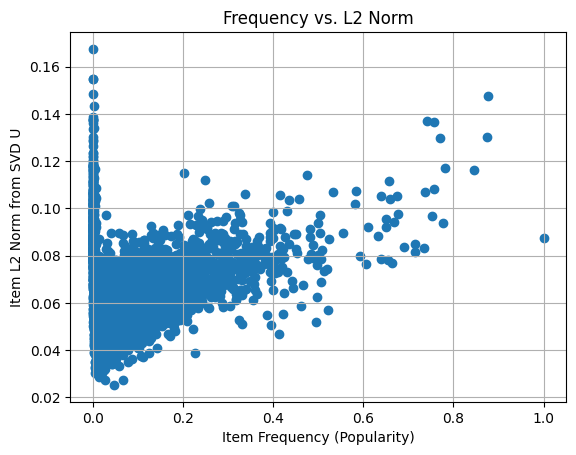

In [77]:
plt.scatter(data["Freq"], data["l2_norm"])
plt.xlabel("Item Frequency (Popularity)")
plt.ylabel("Item L2 Norm from SVD U")
plt.title("Frequency vs. L2 Norm")
plt.grid(True)
plt.show()


In [79]:
top_freq = set(data.sort_values("Freq", ascending=False).head(50)["ItemID"])
top_norm = set(data.sort_values("l2_norm", ascending=False).head(50)["ItemID"])

print("Top-50 overlap:", len(top_freq.intersection(top_norm)))


Top-50 overlap: 7
